=== FIRST 5 ROWS ===
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            6  156.541513      73.894220      26.739663  122.757807   
1            3  108.316259      90.103519      34.078719  103.084121   
2            7  106.715930      80.667812      24.912094   15.000000   
3            4  131.346798      75.952771      29.514112   90.284269   
4            6  178.015194      70.666866      33.158516  282.278298   

         BMI  DiabetesPedigreeFunction  Age  Outcome  
0  39.725669                  2.304827   21        1  
1  44.077914                  1.541463   31        0  
2  27.596496                  2.358101   23        0  
3  30.820109                  2.084413   72        1  
4  28.855853                  1.700732   43        0  

=== DATASET SHAPE ===
(200, 9)

=== DESCRIPTIVE STATISTICS ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   200.000000  200.000000     200.000000     200.000000  200.000000   


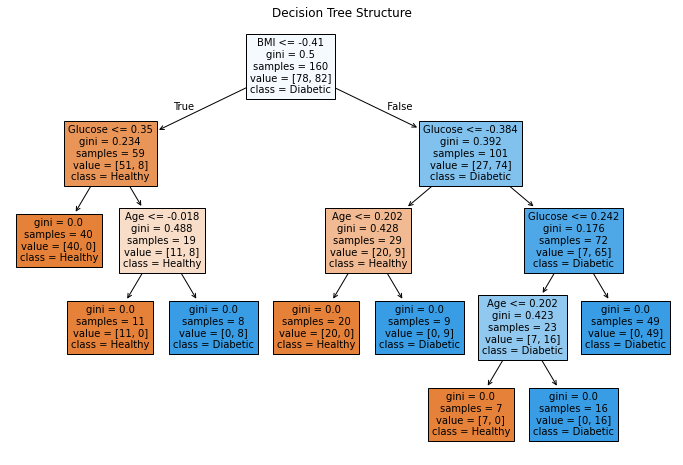


=== FEATURE IMPORTANCE ===
Age                         0.392947
BMI                         0.332147
Glucose                     0.274907
Pregnancies                 0.000000
BloodPressure               0.000000
SkinThickness               0.000000
Insulin                     0.000000
DiabetesPedigreeFunction    0.000000
dtype: float64


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ==========================================
# 1. Data Loading & Exploration
# ==========================================
# Load the dataset (update the path if necessary for production)
df = pd.read_csv(r"D:\myprojects\diabetes-risk-prediction\data\raw\medical_decision_dataset.csv")

print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== DATASET SHAPE ===")
print(df.shape)  # Expected: (200, 9)

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# ==========================================
# 2. Data Preprocessing & Splitting
# ==========================================
# Separate features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Standardize features (critical distance-based scaling for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==========================================
# 3. Model Training
# ==========================================
# Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# K-Nearest Neighbors Classifier (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Decision Tree Classifier (constrained max_depth for regularization)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# ==========================================
# 4. Model Evaluation
# ==========================================
print("\n=== ACCURACY SCORES ===")
print(f"Naïve Bayes    : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"KNN (k=5)      : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Decision Tree  : {accuracy_score(y_test, y_pred_tree):.4f}")

print("\n=== CONFUSION MATRICES ===")
print("Naïve Bayes:\n", confusion_matrix(y_test, y_pred_nb))
print("KNN:\n", confusion_matrix(y_test, y_pred_knn))
print("Decision Tree:\n", confusion_matrix(y_test, y_pred_tree))

print("\n=== CLASSIFICATION REPORTS ===")
print("Naïve Bayes:\n", classification_report(y_test, y_pred_nb))
print("KNN:\n", classification_report(y_test, y_pred_knn))
print("Decision Tree:\n", classification_report(y_test, y_pred_tree))

# ==========================================
# 5. Visualization & Feature Importance
# ==========================================
# Plot the decision tree structure
plt.figure(figsize=(12, 8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Healthy", "Diabetic"],
    filled=True,
)
plt.title("Decision Tree Structure")
plt.show()

# Extract and display feature importance scores
importance = pd.Series(tree.feature_importances_, index=X.columns)
print("\n=== FEATURE IMPORTANCE ===")
print(importance.sort_values(ascending=False))